In [1]:
import json
import random
import re

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shapely
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial import cKDTree
from shapely import wkt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from helpers.comparison_helpers import *
from helpers.simplecube_helpers import *

path = "./dataset/samples"

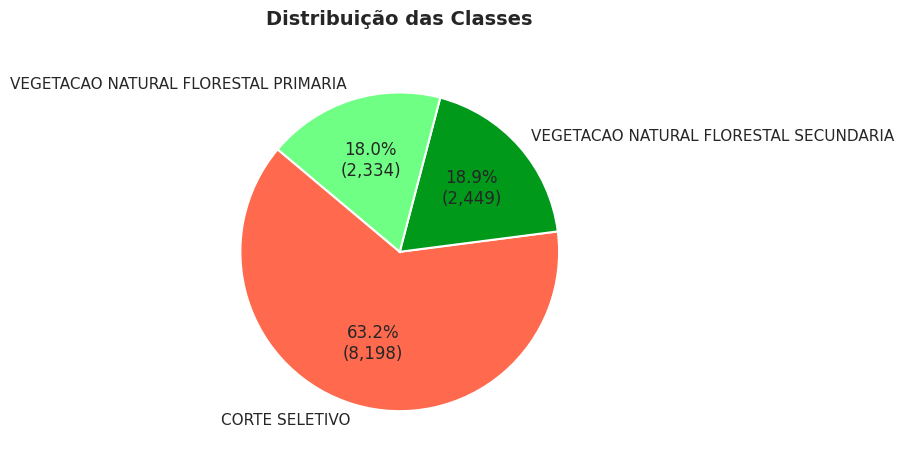


--- Diagnóstico: All tiles (2024) ---
=== AlphaEarth ===
Linhas: 12981
CRS declarado: EPSG:4326
Exemplo Geom: POINT (-61.204421, -8.232206)
Bounding Box: [-61.24996576 -10.00000083 -58.75013399  -2.50005635]

=== Tessera ===
Linhas: 12981
CRS declarado: EPSG:4326
Exemplo Geom: POINT (-61.204400, -8.232186)
Bounding Box: [-61.249937 -10.000044 -58.750097  -2.50004 ]

=== Sentinel-2 ===
Linhas: 12981
CRS declarado: EPSG:4326
Exemplo Geom: POINT (-61.204400, -8.232186)
Bounding Box: [-61.24993716 -10.00004417 -58.75009716  -2.50003992]


--- Diagnóstico: C51L41 (2024) ---
=== AlphaEarth ===
Linhas: 6682
CRS declarado: EPSG:4326
Exemplo Geom: POINT (-61.204421, -8.232206)
Bounding Box: [-61.24996576  -8.24999282 -61.00023412  -7.99999168]

=== Tessera ===
Linhas: 6682
CRS declarado: EPSG:4326
Exemplo Geom: POINT (-61.204400, -8.232186)
Bounding Box: [-61.249937  -8.249997 -61.000277  -7.999974]

=== Sentinel-2 ===
Linhas: 6682
CRS declarado: EPSG:4326
Exemplo Geom: POINT (-61.204400, -8.2

In [16]:
year = 2024
tiles = ["C51L41", "C51L34", "C60L63"]
sources = ["alphaearth",  "tessera", "sentinel2"]
cores_classes = {
    "CORTE SELETIVO": "#FF694D",
    "VEGETACAO NATURAL FLORESTAL SECUNDARIA": "#00991A",
    "VEGETACAO NATURAL FLORESTAL PRIMARIA": "#70FF85",
    # --- CORTE SELETIVO ---
    "(C51L34) CORTE SELETIVO": "#C4280E",
    "(C51L41) CORTE SELETIVO": "#FF4500",
    "(C60L63) CORTE SELETIVO": "#FF9E8C",
    # --- VEGETAÇÃO NATURAL FLORESTAL SECUNDÁRIA ---
    "(C51L34) VEGETACAO NATURAL FLORESTAL SECUNDARIA": "#00520E",
    "(C51L41) VEGETACAO NATURAL FLORESTAL SECUNDARIA": "#00BD20",
    "(C60L63) VEGETACAO NATURAL FLORESTAL SECUNDARIA": "#4DE066",
    # --- VEGETAÇÃO NATURAL FLORESTAL PRIMÁRIA ---
    "(C51L34) VEGETACAO NATURAL FLORESTAL PRIMARIA": "#36D94E",
    "(C51L41) VEGETACAO NATURAL FLORESTAL PRIMARIA": "#9EFFAD",
    "(C60L63) VEGETACAO NATURAL FLORESTAL PRIMARIA": "#D1FFD7",
}

dataset = {"all": {}}

for src in sources:
    all_ = []
    for tile in tiles:
        df = None
        if src == "sentinel2":
            file_path = f"{path}/samples_{tile}_{year}_{src}_pixel.csv"
            df = read_gdf(file_path)
            df["tile"] = tile
        else:
            file_path = f"{path}/samples_{tile}_{year}_embeddings_{src}_pixel.csv"
            df = read_gdf(file_path)
        all_.append(df)
    dataset["all"][src] = pd.concat(all_, ignore_index=True)
    dataset["all"][src]["label_"] = "(" + dataset["all"][src]["tile"] + ") " + dataset["all"][src]["label"]

gdfs_alinhados = find_commom_geoms_nearest([
    dataset["all"]["alphaearth"],
    dataset["all"]["tessera"],
    dataset["all"]["sentinel2"]
], max_distance_meters=5)
dataset["all"]["alphaearth"] = gdfs_alinhados[0]
dataset["all"]["tessera"]    = gdfs_alinhados[1]
dataset["all"]["sentinel2"]  = gdfs_alinhados[2]

plot_balance(dataset["all"]["alphaearth"], "label", f"Distribuição das Classes", cores_classes)

print(f"\n--- Diagnóstico: All tiles ({year}) ---")
check_gdfs(
    [dataset["all"]["alphaearth"], dataset["all"]["tessera"], dataset["all"]["sentinel2"]],
    ["AlphaEarth", "Tessera", "Sentinel-2"]
)

for tile in tiles:
    dataset[tile] = {}
    for src in sources:
        if src == "sentinel2":
            file_path = f"{path}/samples_{tile}_{year}_{src}_pixel.csv"
        else:
            file_path = f"{path}/samples_{tile}_{year}_embeddings_{src}_pixel.csv"
        dataset[tile][src] = read_gdf(file_path)
    gdfs_alinhados = find_commom_geoms_nearest([
        dataset[tile]["alphaearth"],
        dataset[tile]["tessera"],
        dataset[tile]["sentinel2"]
    ], max_distance_meters=5)
    dataset[tile]["alphaearth"] = gdfs_alinhados[0]
    dataset[tile]["tessera"]    = gdfs_alinhados[1]
    dataset[tile]["sentinel2"]  = gdfs_alinhados[2]

    print(f"\n--- Diagnóstico: {tile} ({year}) ---")
    check_gdfs(
        [dataset[tile]["alphaearth"], dataset[tile]["tessera"], dataset[tile]["sentinel2"]],
        ["AlphaEarth", "Tessera", "Sentinel-2"]
    )

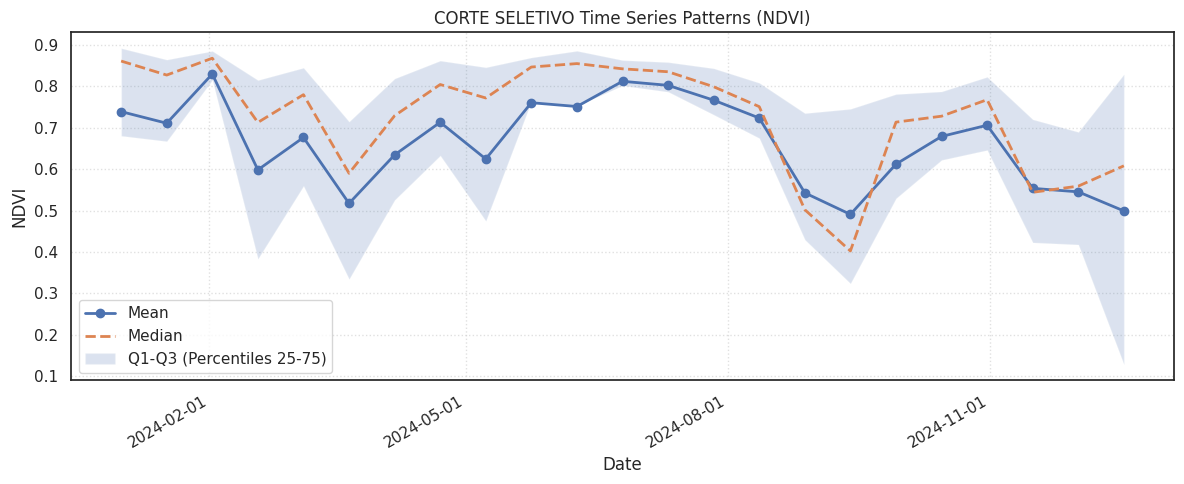

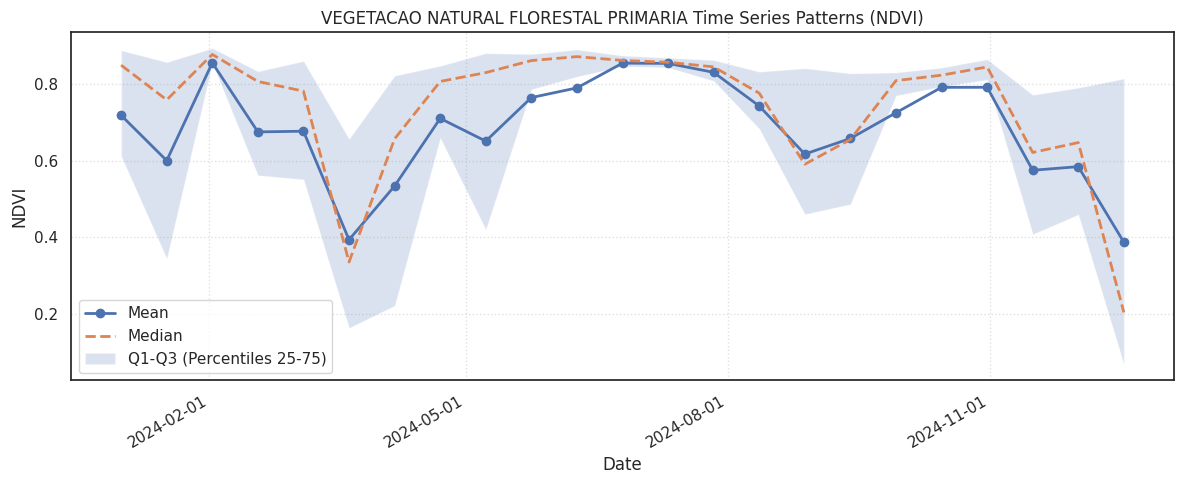

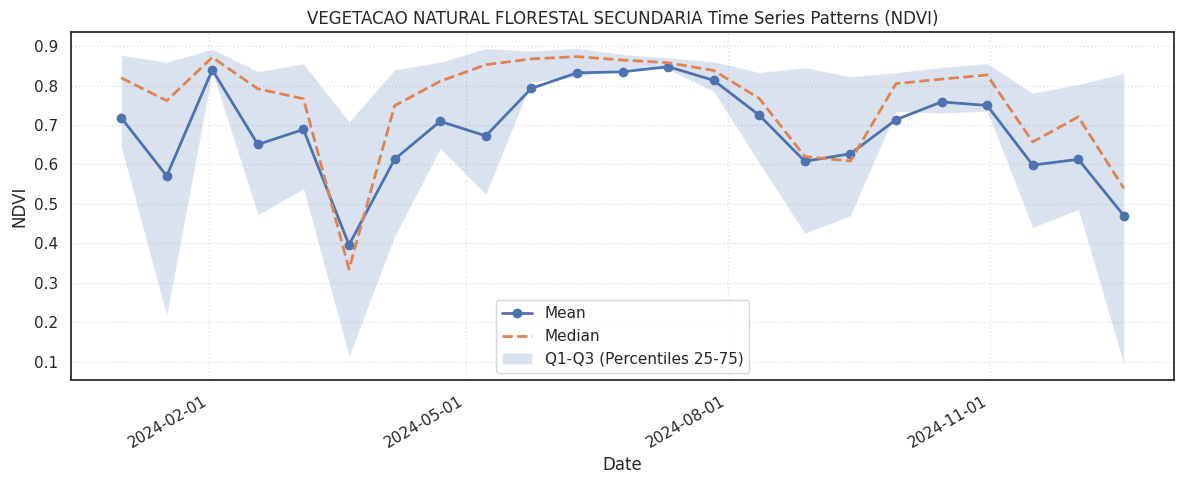

In [18]:
tile = "all"
# tile = tiles[0]
label_column = "label"

samples = dataset[tile]["sentinel2"].copy()
samples["label"] = samples[label_column]
samples = extract_bands(samples, ["ndvi"])
plot_patterns(samples, "ndvi")

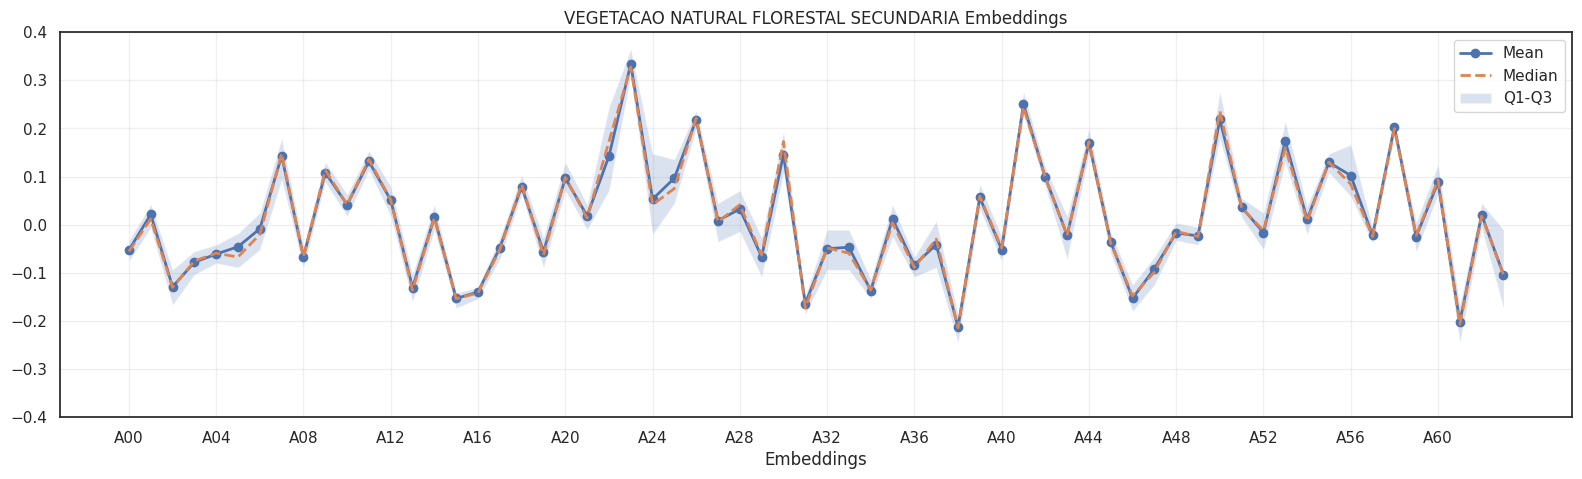

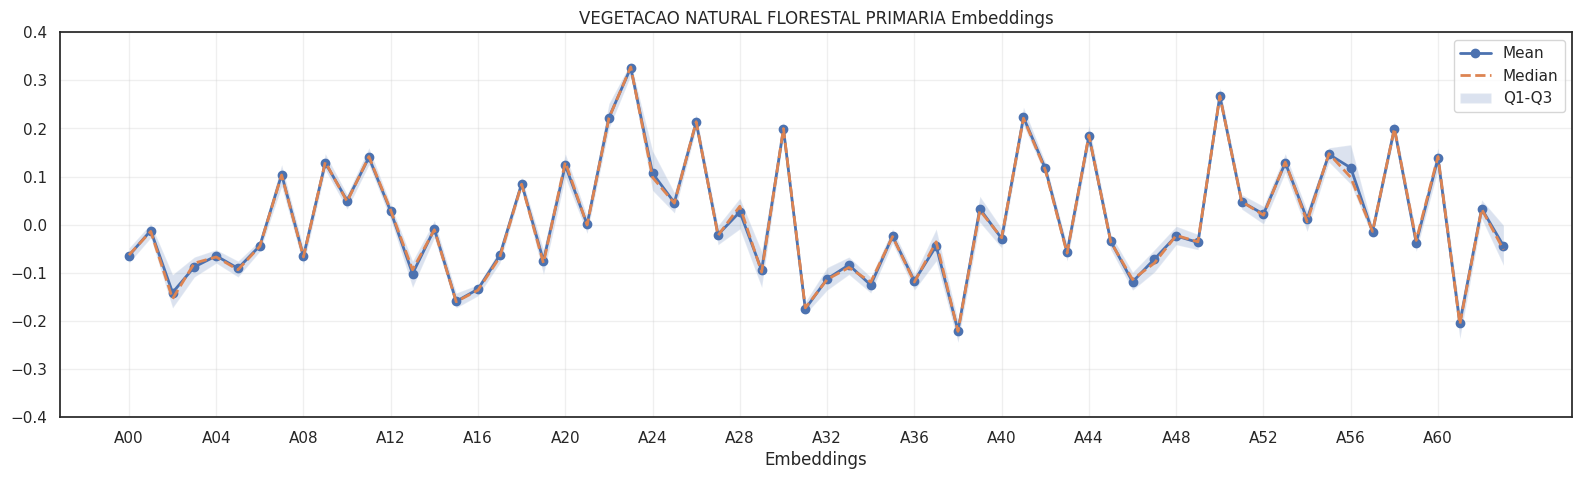

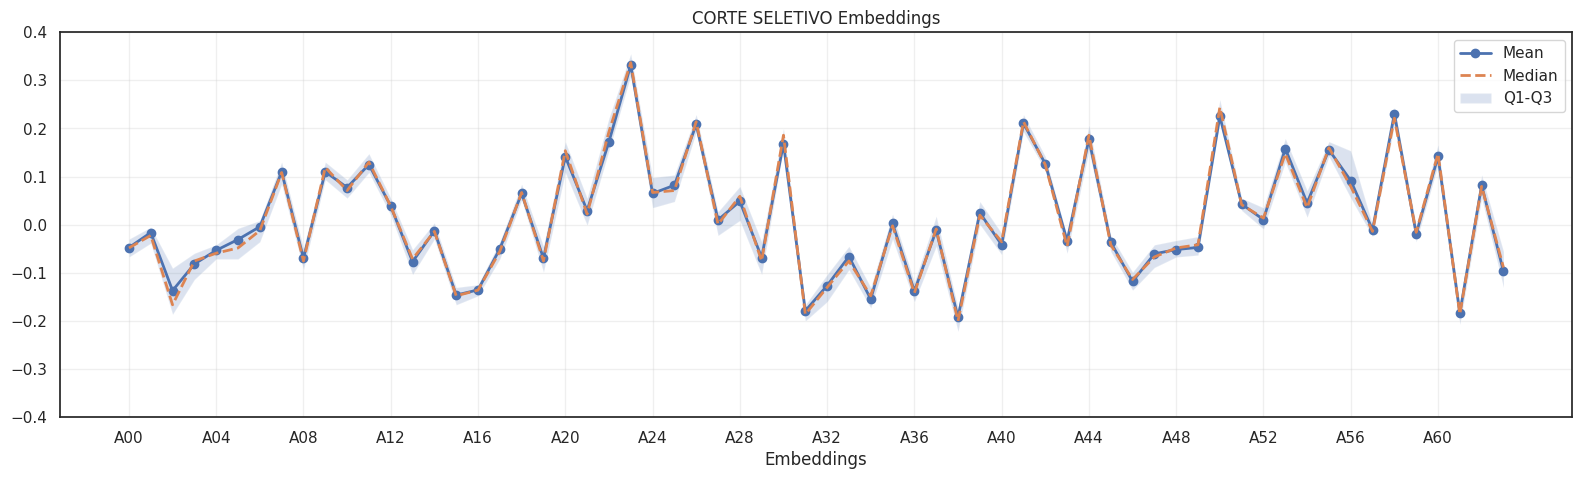

In [22]:
tile = "all"
# tile = tiles[0]
label_column = "label"

samples_embeddings = dataset[tile]["alphaearth"].copy()
labels = set(samples_embeddings[label_column])
column_names = list([(f"A{i}" if i > 9 else f"A0{i}") for i in range(0, 64)])
for label in labels:
    data_ = samples_embeddings[samples_embeddings["label"] == label]
    generatePlotFigPatternsAlphaEarth(data_[column_names], label)

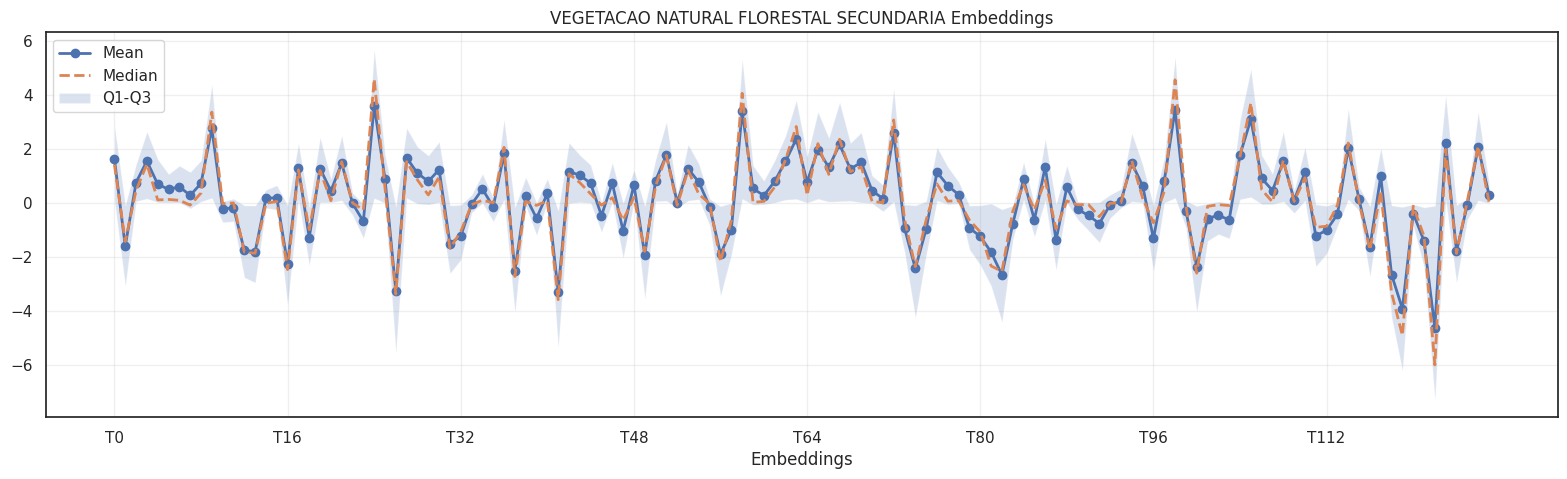

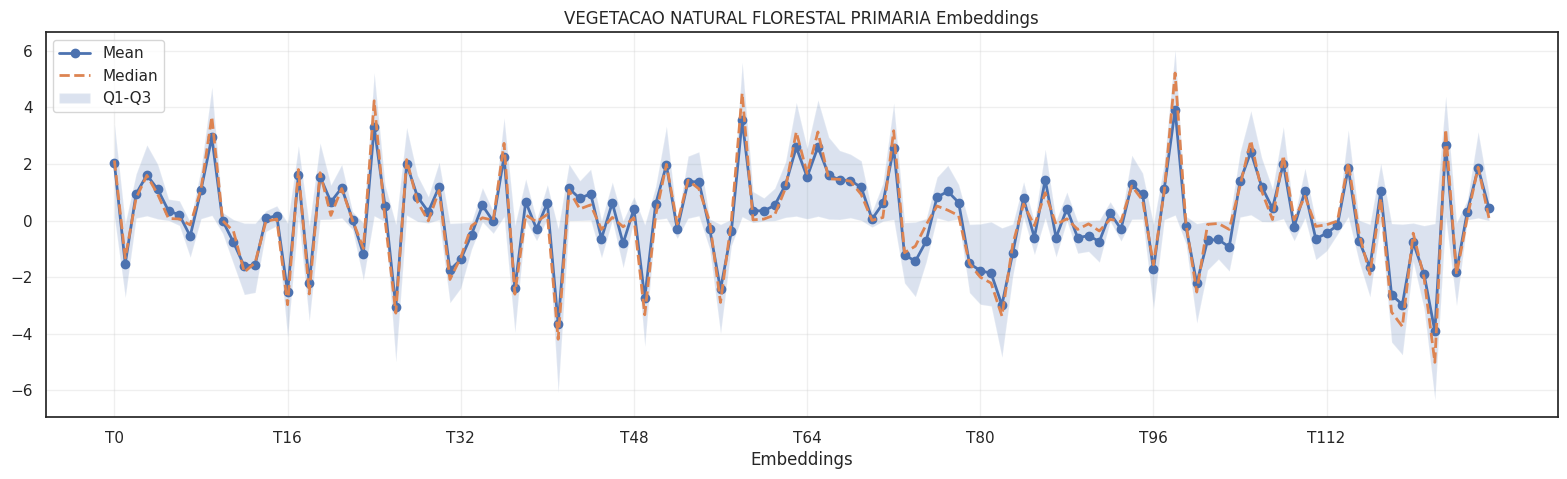

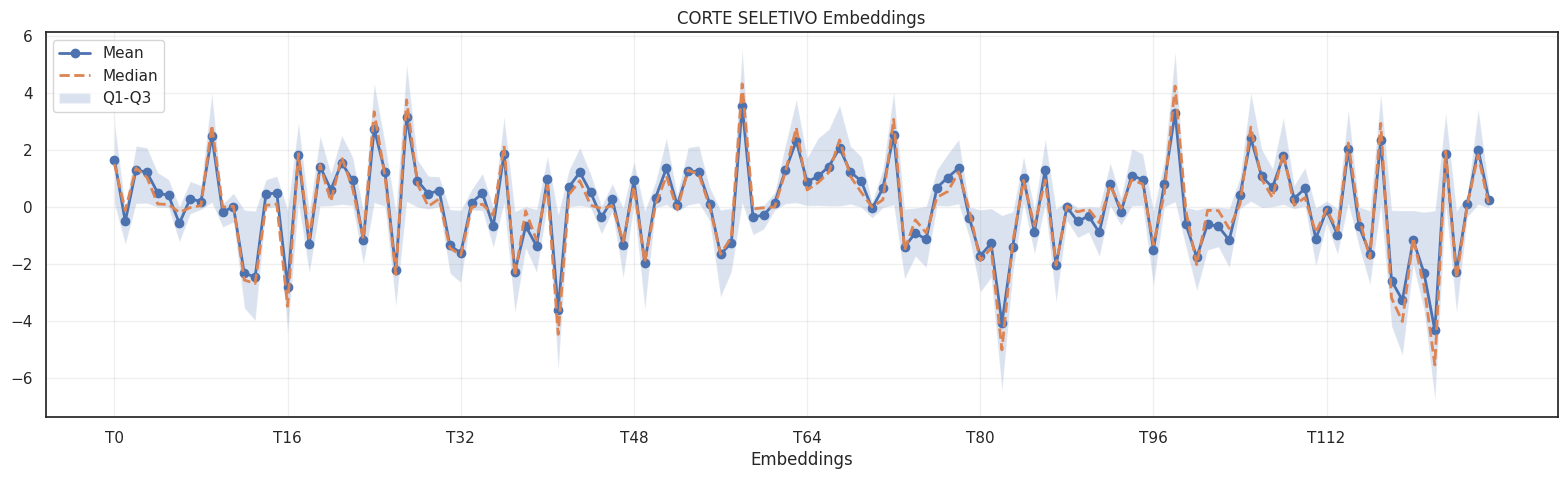

In [24]:
tile = "all"
# tile = tiles[0]
label_column = "label"

samples_embeddings = dataset[tile]["tessera"].copy()
labels = set(samples_embeddings[label_column])
column_names = [f"T{i}" for i in range(128)]
for label in labels:
    data_ = samples_embeddings[samples_embeddings["label"] == label]
    generatePlotFigPatternsTessera(data_[column_names], label)

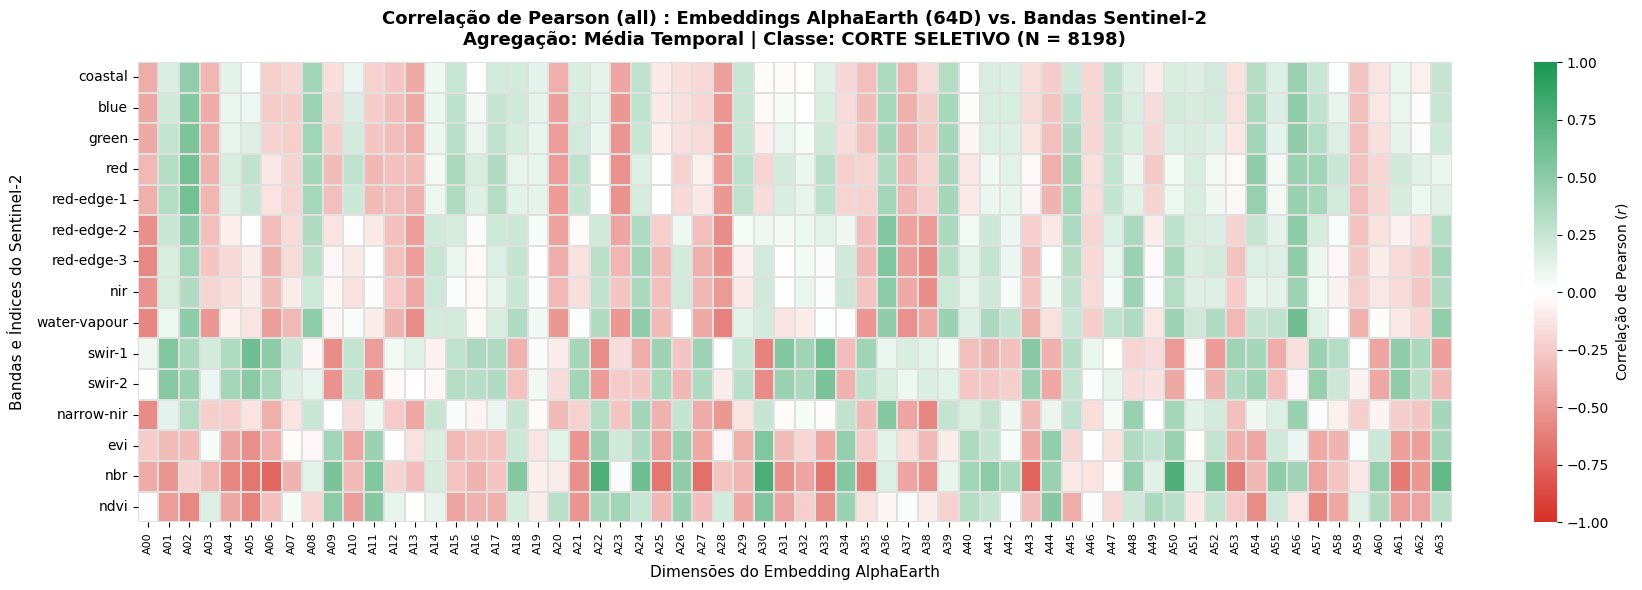

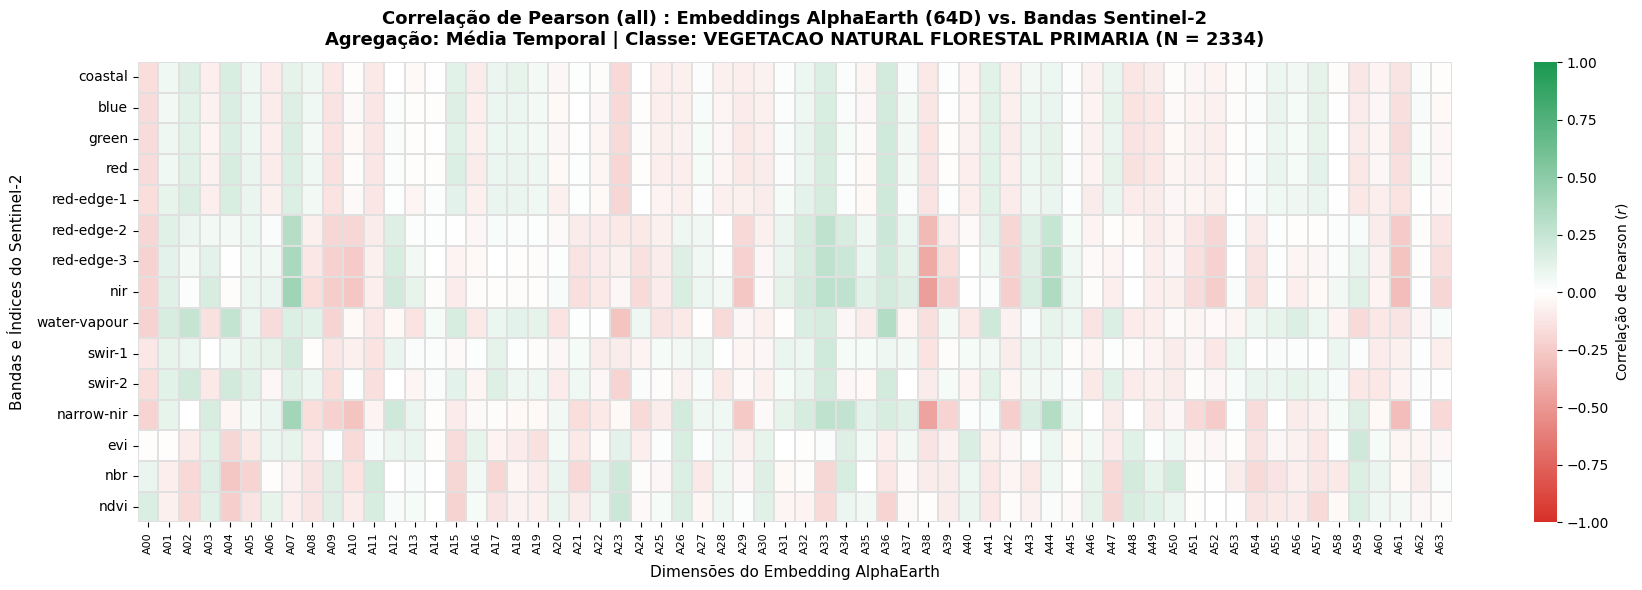

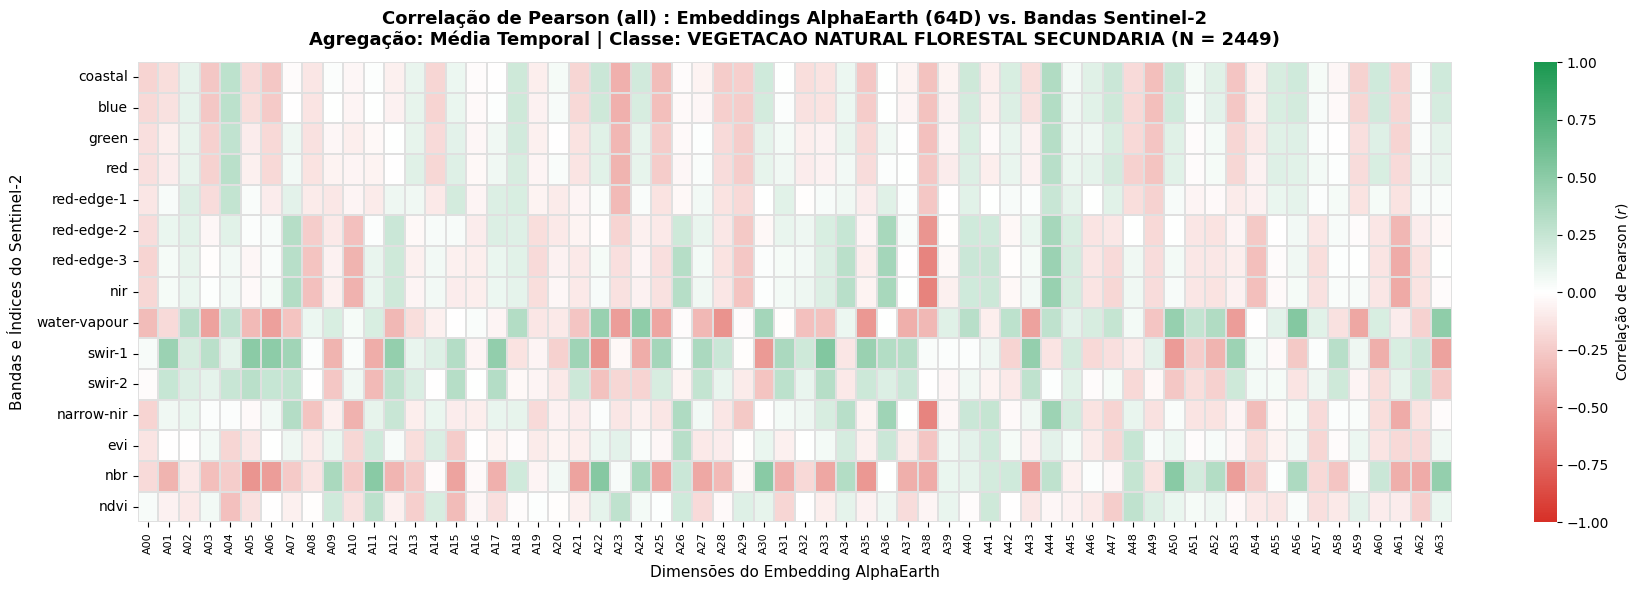

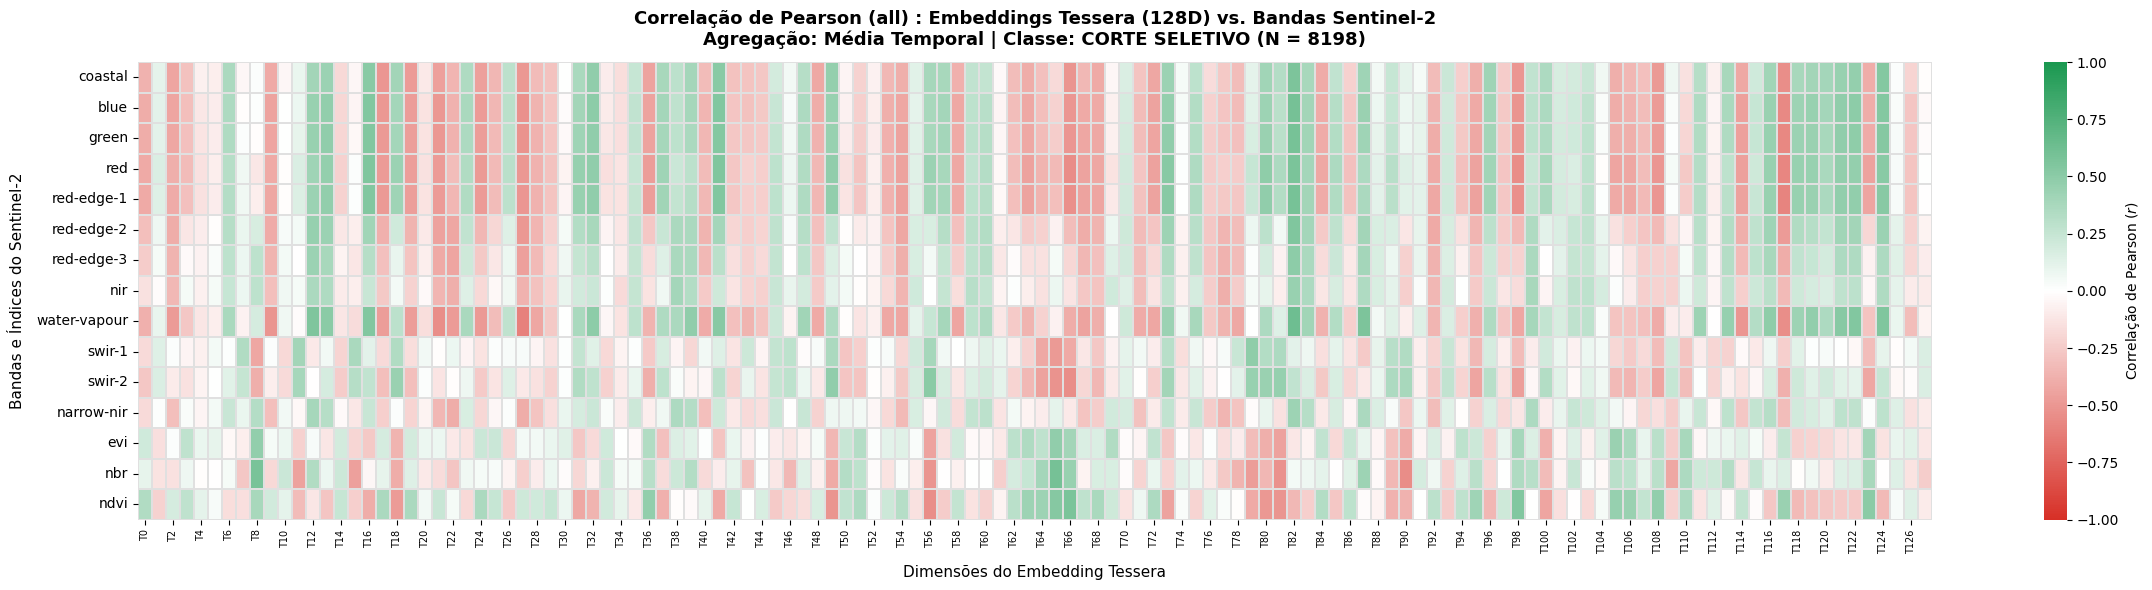

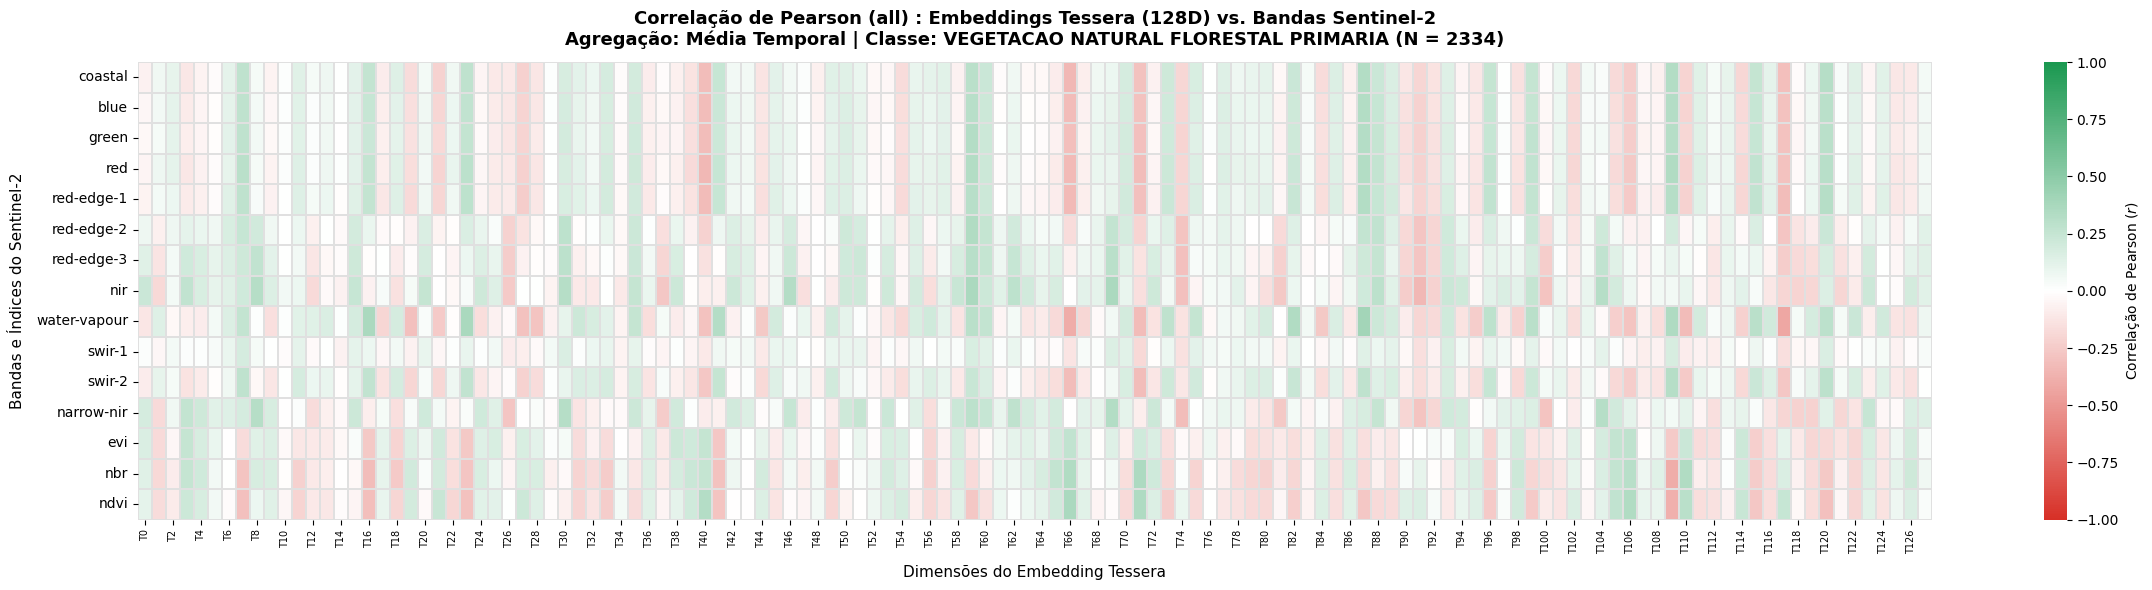

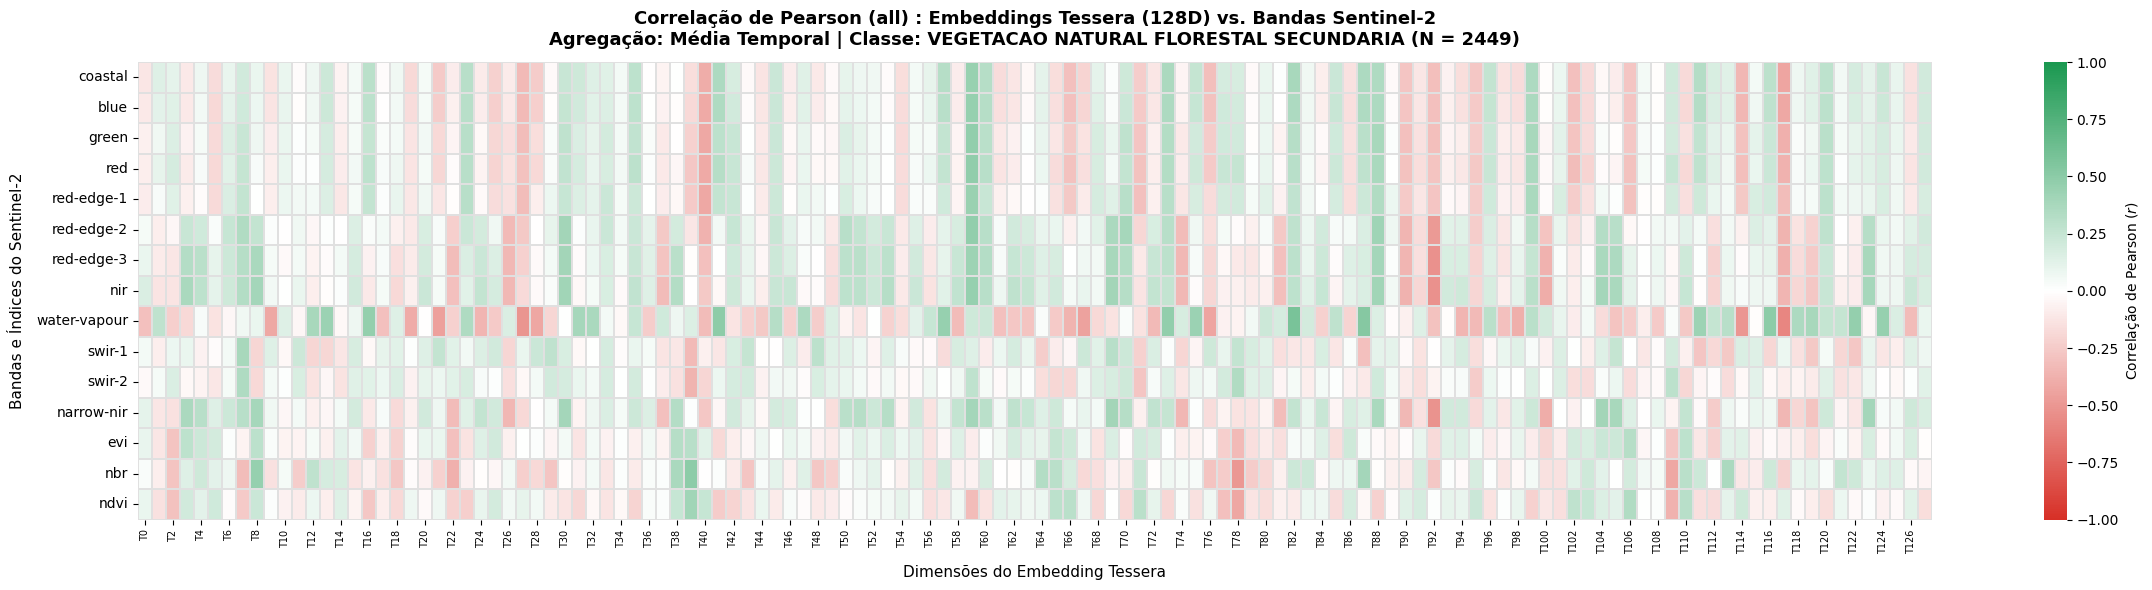

In [6]:
label_columns = "label"
tile = "all"
method = "mean"

mode = "alphaearth"

plot_heatmap(
    dataset[tile][mode],
    dataset[tile]["sentinel2"],
    embedding_type=mode,
    agg_method=method,
    label_col=label_columns,
    roi_name=tile
)

mode = "tessera"

plot_heatmap(
    dataset[tile][mode],
    dataset[tile]["sentinel2"],
    embedding_type=mode,
    agg_method=method,
    label_col=label_columns,
    roi_name=tile
)

PCA (2 componentes) - Variância explicada total: 44.89%
PCA (3 componentes) - Variância explicada total: 56.98%


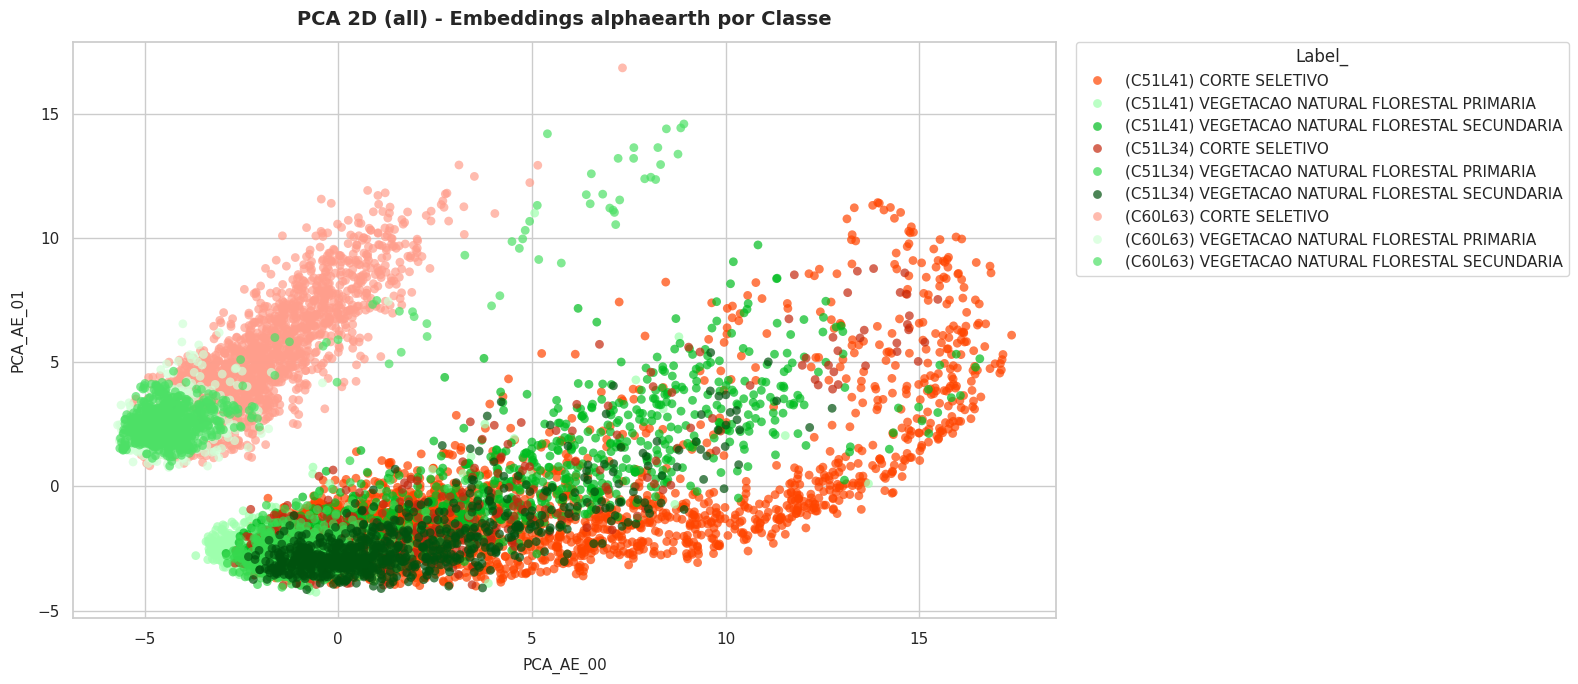

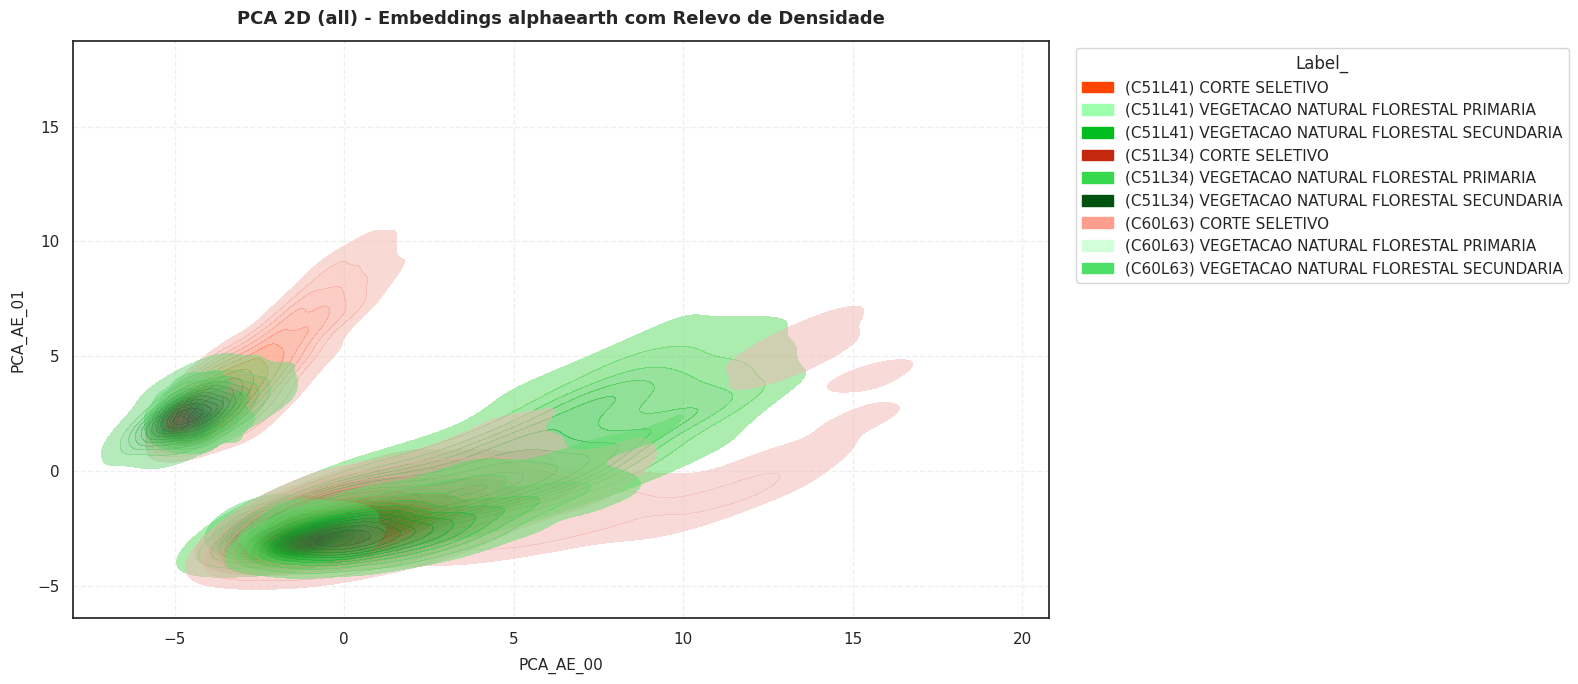

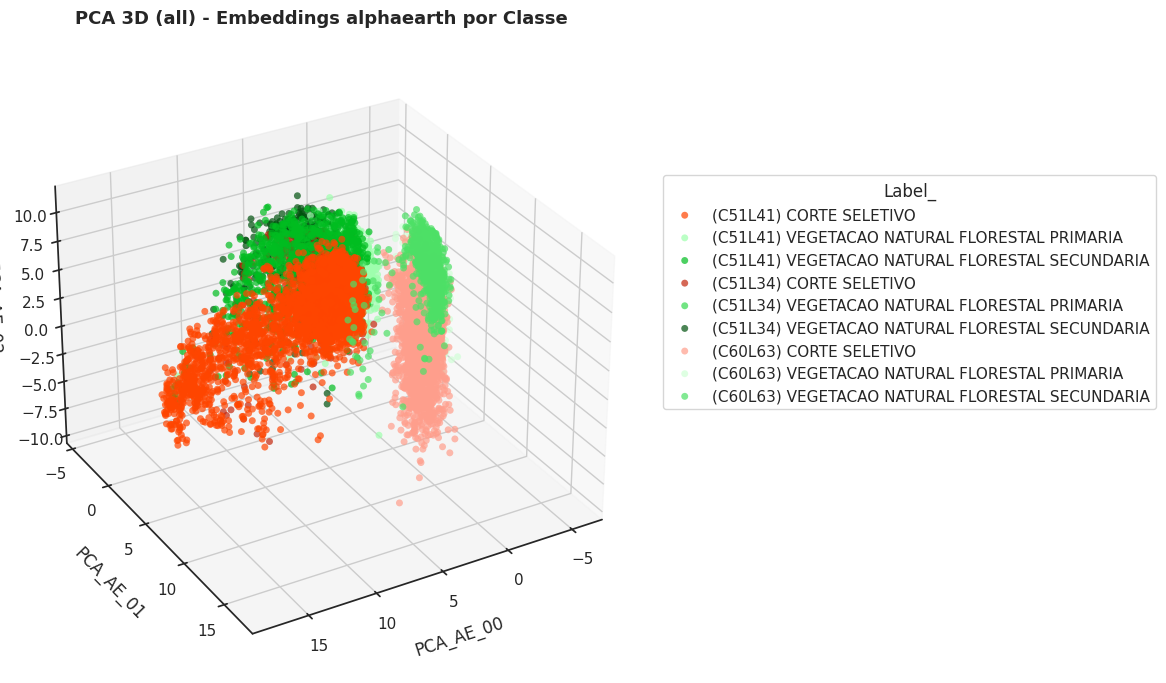

In [7]:
tile = "all"
# tile = tiles[0]
mode = "alphaearth"
label_column = "label_"

gdf_2d = reduce_embeddings(
    gdf = dataset[tile][mode],
    embedding_type=mode,
    n_components=2,
    method="pca",
    random_state=88,
)

gdf_3d = reduce_embeddings(
    gdf = dataset[tile][mode],
    embedding_type=mode,
    n_components=3,
    method="pca"
)

plot_reduced_embeddings_2d(
    gdf=gdf_2d,
    label_col=label_column,
    color_palette=cores_classes,
    title=f"PCA 2D ({tile}) - Embeddings {mode} por Classe",
    figsize = (16, 7)
)

plot_embeddings_density_relief_2d(
    gdf=gdf_2d,
    label_col=label_column,
    color_palette=cores_classes,
    levels=12,
    thresh=0.08,
    title=f"PCA 2D ({tile}) - Embeddings {mode} com Relevo de Densidade",
    figsize = (16, 7)
)

plot_reduced_embeddings_3d(
    gdf=gdf_3d,
    label_col=label_column,
    color_palette=cores_classes,
    title=f"PCA 3D ({tile}) - Embeddings {mode} por Classe",
    figsize = (25, 7),
    elev=30,
    azim=60
)

PCA (2 componentes) - Variância explicada total: 43.75%
PCA (3 componentes) - Variância explicada total: 52.70%


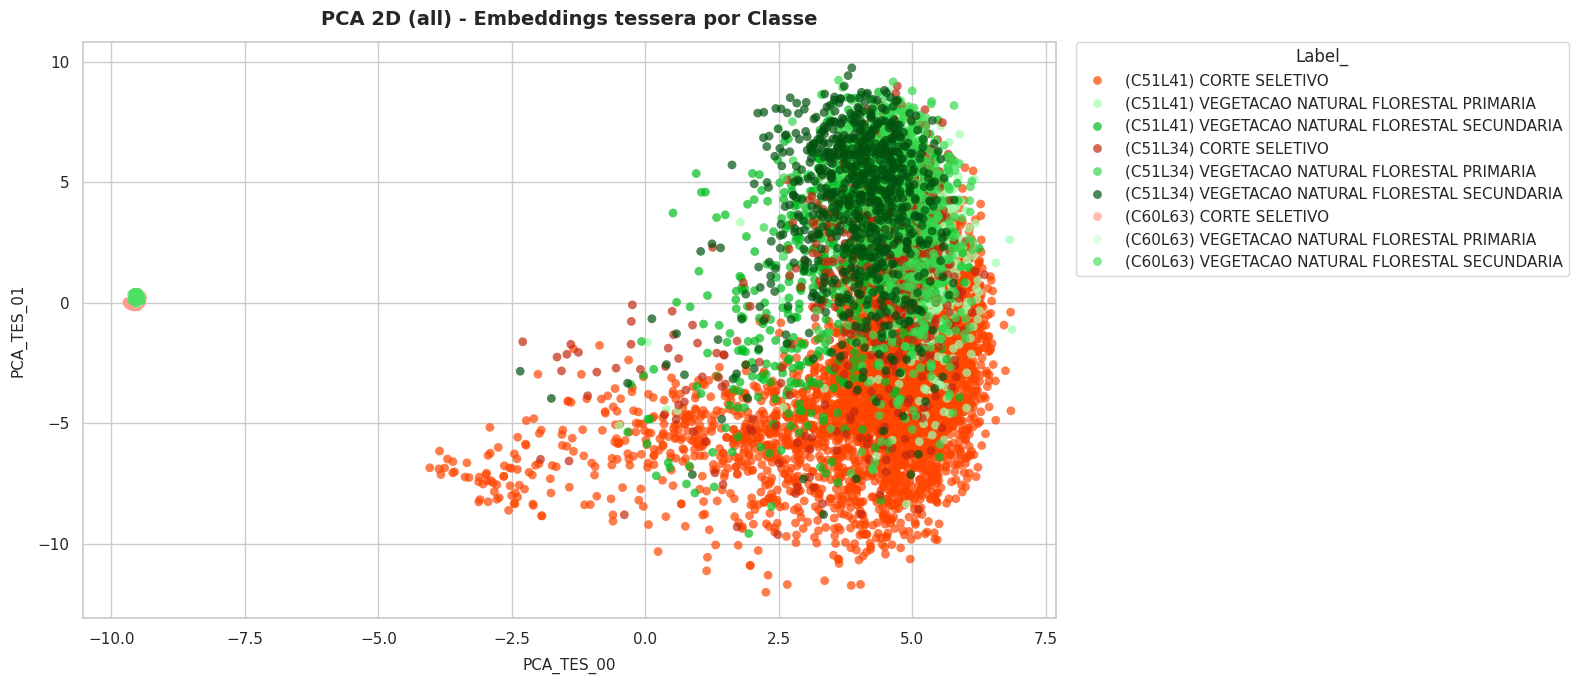

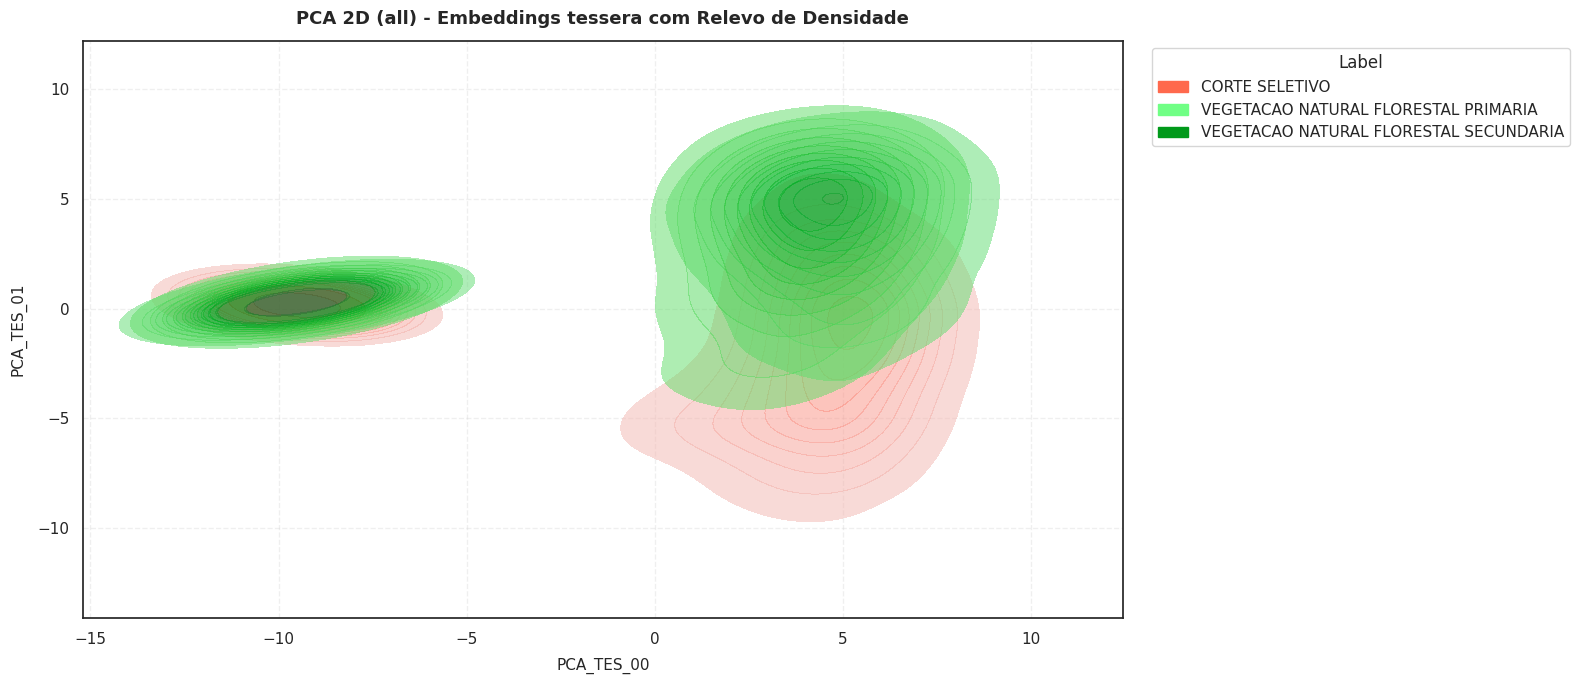

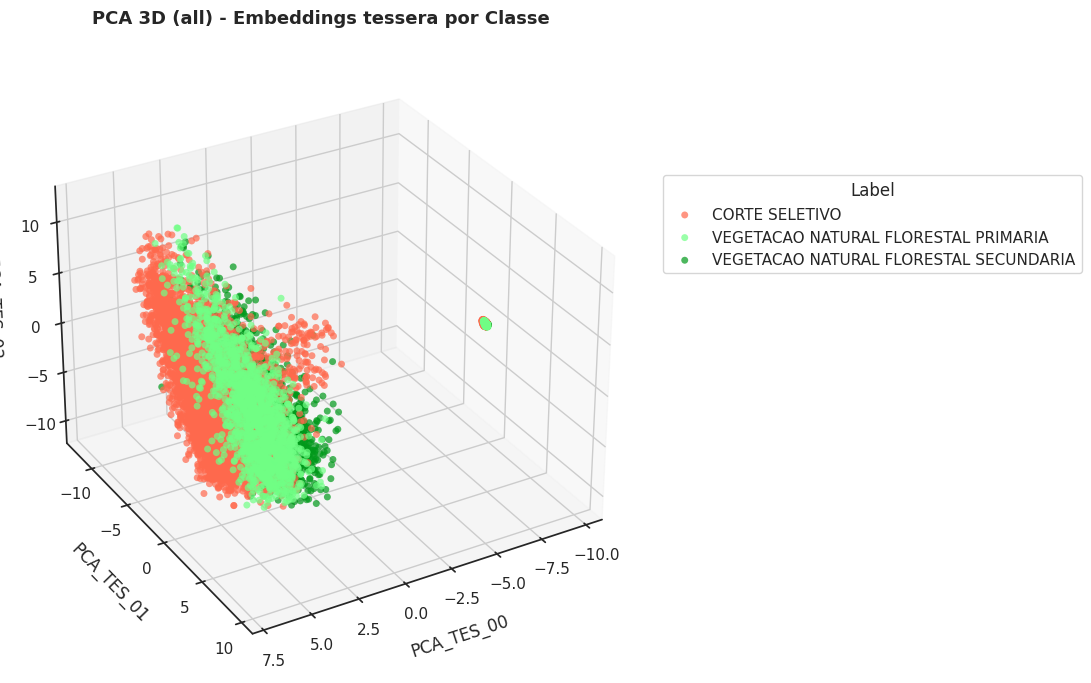

In [9]:
tile = "all"
# tile = tiles[0]
mode = "tessera"
label_column = "label_"

gdf_2d = reduce_embeddings(
    gdf = dataset[tile][mode],
    embedding_type=mode,
    n_components=2,
    method="pca",
    random_state=88,
)

gdf_3d = reduce_embeddings(
    gdf = dataset[tile][mode],
    embedding_type=mode,
    n_components=3,
    method="pca"
)

plot_reduced_embeddings_2d(
    gdf=gdf_2d,
    label_col=label_column,
    color_palette=cores_classes,
    title=f"PCA 2D ({tile}) - Embeddings {mode} por Classe",
    figsize = (16, 7)
)

label_column = "label"

plot_embeddings_density_relief_2d(
    gdf=gdf_2d,
    label_col=label_column,
    color_palette=cores_classes,
    levels=12,
    thresh=0.08,
    title=f"PCA 2D ({tile}) - Embeddings {mode} com Relevo de Densidade",
    figsize = (16, 7)
)

plot_reduced_embeddings_3d(
    gdf=gdf_3d,
    label_col=label_column,
    color_palette=cores_classes,
    title=f"PCA 3D ({tile}) - Embeddings {mode} por Classe",
    figsize = (25, 7),
    elev=30,
    azim=60
)

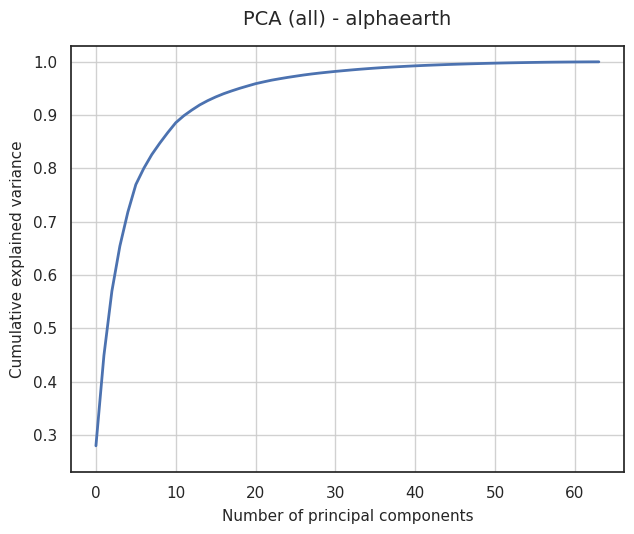

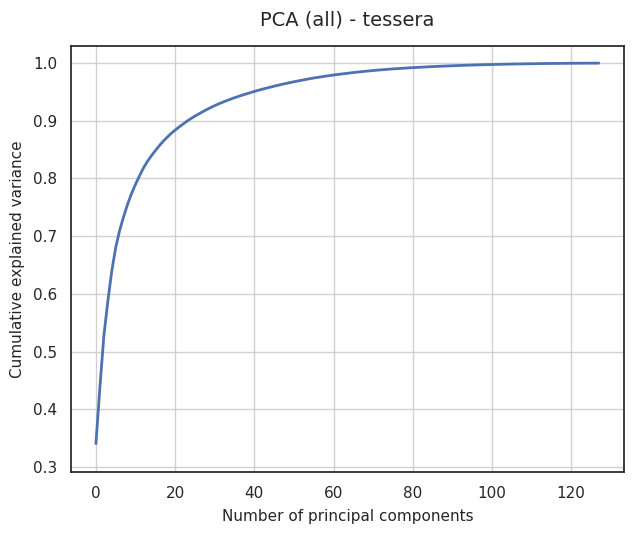

In [11]:
tile = "all"
# tile = tiles[0]
mode = "alphaearth"

plot_pca_cumulative_variance(dataset[tile][mode], title = f"PCA ({tile}) - {mode}")

tile = "all"
# tile = tiles[0]
mode = "tessera"

plot_pca_cumulative_variance(dataset[tile][mode], title = f"PCA ({tile}) - {mode}")